# QMC on Manifolds

## Setup

In [1]:
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import scipy.stats
import qmcpy as qp
import time
import os
# import qmcpy as qp
import matplotlib
from matplotlib import pyplot
pyplot.style.use("seaborn-v0_8-whitegrid")
# import pandas as pd
# COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv("../../../xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
# pyplot.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=COLORS)
COLORS = ["xkcd:purple","xkcd:blue","xkcd:green","xkcd:red","xkcd:orange","xkcd:cyan","xkcd:brown","xkcd:yellow"]
LINESTYLES = ['solid','dotted','dashed','dashdot',(0, (1, 1))]
DEFAULTFONTSIZE = 30
pyplot.rcParams['xtick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['ytick.labelsize'] = DEFAULTFONTSIZE
pyplot.rcParams['axes.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams['figure.titlesize'] = DEFAULTFONTSIZE
pyplot.rcParams["axes.labelsize"] = DEFAULTFONTSIZE
pyplot.rcParams['legend.fontsize'] = DEFAULTFONTSIZE
pyplot.rcParams['font.size'] = DEFAULTFONTSIZE
pyplot.rcParams['lines.linewidth'] = 5
pyplot.rcParams['lines.markersize'] = 15
PW = 30 # inches

## Sphere

In [12]:
def kernel_sphere_a(x, y):
    assert x.size(-1)==3
    assert y.size(-1)==3
    y = 2-torch.linalg.norm(x-y,dim=-1)
    return y/(2/3)
def kernel_sphere_b(x, y):
    assert x.size(-1)==3 
    assert y.size(-1)==3
    y = 48*torch.exp(-12*torch.linalg.norm(x-y,dim=-1)**2)
    return y/(1-np.exp(-48))
def unif_to_sphere(x):
    assert x.size(-1)==2
    t = torch.sqrt(x[...,1]-x[...,1]**2)
    y = torch.stack([
        2*torch.cos(2*np.pi*x[...,0])*t,
        2*torch.sin(2*np.pi*x[...,0])*t,
        1-2*x[...,1]
        ],axis=-1)
    return y
def discrepancy(kernel, x, w, return_kmat=False):
    assert x.ndim>=2
    assert x.size(-2)==w.size(-1)
    kmat = kernel(x[...,:,None,:],x[...,None,:,:]) # (...,n,n)
    discrep = torch.einsum("...i,...ij,...j->...",w,kmat,w)-1 # (...,)
    if return_kmat:
        return discrep,kmat 
    else:
        return discrep

In [ ]:
def opt_weights(x, kernel):
    kmat = kernel(x[...,:,None,:],x[...,None,:,:]) # (...,n,n)
    b = torch.ones(kmat.size(-1)) # (...,n,)
    L = torch.linalg.cholesky(kmat,upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w
def opt_points_weights(
        n,
        kernel,
        opt_iters = 100,
        eps_kmat = 1e-3,
        lm_relaxation = 1e0,
        lm_relaxation_threshold = 1,
        lm_lr = .25,
        rng = None
        ):
    if rng is None: rng = torch.Generator()
    uomega = torch.cat([torch.randn(n-1,2,generator=rng)/10,torch.randn(n-1,generator=rng)[:,None]/n],dim=-1).flatten() # ((n-1)*(2+1),)
    eyen = torch.eye(n)
    eyeQ = torch.eye((n-1)*3)
    for i in range(opt_iters+1):
        notes = ""
        def discrepancy_loss(uomega):
            uw2d = uomega.reshape((n-1,2+1))
            u,omega = uw2d[:,:-1],uw2d[:,-1]
            u = torch.cat([torch.zeros((1,2)),u],dim=0)
            w = torch.cat([1-omega.sum(dim=-1,keepdim=True),omega],dim=0)
            x = unif_to_sphere(torch.nn.functional.sigmoid(u))
            discrep,kmat = discrepancy(kernel,x,w,return_kmat=True)
            L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False)
            v = torch.einsum("i,ij->j",w,L)
            return v,(v,x,w,discrep)
        (J,),(resid,x,w,discrep) = torch.func.jacrev(discrepancy_loss,argnums=(0,),has_aux=True)(uomega)
        print(discrep)
        if i==opt_iters: break
        H = torch.einsum("ij,ik->jk",J,J) # (Q,Q)
        fails = True # flags for Cholesky factorization failure
        while True: # continue to double lm_relaxation until the Cholesky factorization doesn't fail
            L,fails = torch.linalg.cholesky_ex(H+lm_relaxation*eyeQ,upper=False)
            fails = fails.to(bool)
            if ~fails: break
            if lm_relaxation>=lm_relaxation_threshold:
                if "LM relax fail, " not in notes:
                    notes += "LM relax fail, "
                break
            lm_relaxation *= 2
        rhs = torch.einsum("ij,i->j",J,resid) # (Q,),  vectorized J^* resid
        delta = torch.cholesky_solve(rhs[:,None],L,upper=False)[:,0] # (R,Q), (J^* J + lm_relaxation I)^{-1} J^* resid
        uomega -= lm_lr*delta # update theta
    print()
    return x,w
opt_points_weights(100, kernel_sphere_b, rng=torch.Generator().manual_seed(17));

tensor(44.1261)
tensor(28.6697)
tensor(19.4415)
tensor(13.8783)
tensor(11.2793)
tensor(10.1792)
tensor(12.0836)
tensor(9.7322)
tensor(8.4743)
tensor(8.2942)
tensor(8.0007)
tensor(7.6479)
tensor(8.3929)
tensor(7.8343)
tensor(6.9140)
tensor(5.9280)
tensor(5.5483)
tensor(4.9654)
tensor(4.8591)
tensor(5.1744)
tensor(5.1039)
tensor(5.5667)
tensor(4.5542)
tensor(4.6606)
tensor(4.2712)
tensor(3.7935)
tensor(3.5026)
tensor(3.2401)
tensor(3.1771)
tensor(2.9592)
tensor(2.8062)
tensor(2.6793)
tensor(2.5900)
tensor(2.5125)
tensor(2.4481)
tensor(2.3915)
tensor(2.3400)
tensor(2.2932)
tensor(2.2493)
tensor(2.2083)
tensor(2.1722)
tensor(2.1412)
tensor(2.1171)
tensor(2.0873)
tensor(2.0715)
tensor(2.0184)
tensor(1.9753)
tensor(1.9339)
tensor(1.8956)
tensor(1.8590)
tensor(1.8273)
tensor(1.7991)
tensor(1.7748)
tensor(1.7520)
tensor(1.7319)
tensor(1.7124)
tensor(1.6948)
tensor(1.6773)
tensor(1.6612)
tensor(1.6453)
tensor(1.6303)
tensor(1.6156)
tensor(1.6015)
tensor(1.5878)
tensor(1.5745)
tensor(1.5616)
ten

In [121]:
def get_sphere_iid_x_equal_w(n, rng=None):
    if rng is None: rng = torch.Generator()
    x = unif_to_sphere(torch.rand(n,2,generator=rng)) # (n,3)
    w = torch.ones(n)/n
    return x,w
def get_sphere_ldtf_x_equal_w(n, rng=None):
    if rng is None: rng = torch.Generator()
    x = unif_to_sphere(torch.from_numpy(qp.DigitalNetB2(2,seed=17,randomize="LMS_DS")(n)))  # (n,3)
    # x = unif_to_sphere(torch.from_numpy(qp.Faure(2,seed=17,randomize="NUS")(n)))  # (n,3)
    w = torch.ones(n)/n
    return x,w
def get_sphere_iid_x_opt_w_A(n, rng=None):
    if rng is None: rng = torch.Generator()
    x = unif_to_sphere(torch.rand(n,2,generator=rng)) # (n,3)
    w = opt_weights(x,kernel_sphere_a)
    return x,w
def get_sphere_iid_x_opt_w_B(n, rng=None):
    if rng is None: rng = torch.Generator()
    x = unif_to_sphere(torch.rand(n,2,generator=rng)) # (n,3)
    w = opt_weights(x,kernel_sphere_b)
    return x,w
def get_sphere_opt_x_opt_w_A(n, rng):
    if rng is None: rng = torch.Generator()
    x,w = opt_points_weights(n,kernel_sphere_a,rng=rng)
    return x,w
def get_sphere_opt_x_opt_w_B(n, rng):
    if rng is None: rng = torch.Generator()
    x,w = opt_points_weights(n,kernel_sphere_b,rng=rng)
    return x,w

tensor(1.8899)
tensor(1.7240)
tensor(1.6022)
tensor(1.4944)
tensor(1.3877)
tensor(1.2780)
tensor(1.1664)
tensor(1.0559)
tensor(0.9499)
tensor(0.8514)
tensor(0.7622)
tensor(0.6832)
tensor(0.6146)
tensor(0.5556)
tensor(0.5056)
tensor(0.4632)
tensor(0.4275)
tensor(0.3974)
tensor(0.3720)
tensor(0.3504)
tensor(0.3321)
tensor(0.3164)
tensor(0.3028)
tensor(0.2911)
tensor(0.2808)
tensor(0.2718)
tensor(0.2639)
tensor(0.2568)
tensor(0.2505)
tensor(0.2448)
tensor(0.2397)
tensor(0.2351)
tensor(0.2309)
tensor(0.2270)
tensor(0.2234)
tensor(0.2202)
tensor(0.2171)
tensor(0.2143)
tensor(0.2117)
tensor(0.2093)
tensor(0.2070)
tensor(0.2048)
tensor(0.2028)
tensor(0.2009)
tensor(0.1991)
tensor(0.1974)
tensor(0.1957)
tensor(0.1942)
tensor(0.1927)
tensor(0.1913)
tensor(0.1899)
tensor(0.1886)
tensor(0.1874)
tensor(0.1862)
tensor(0.1850)
tensor(0.1839)
tensor(0.1828)
tensor(0.1818)
tensor(0.1808)
tensor(0.1798)
tensor(0.1789)
tensor(0.1779)
tensor(0.1771)
tensor(0.1762)
tensor(0.1753)
tensor(0.1745)
tensor(0.1

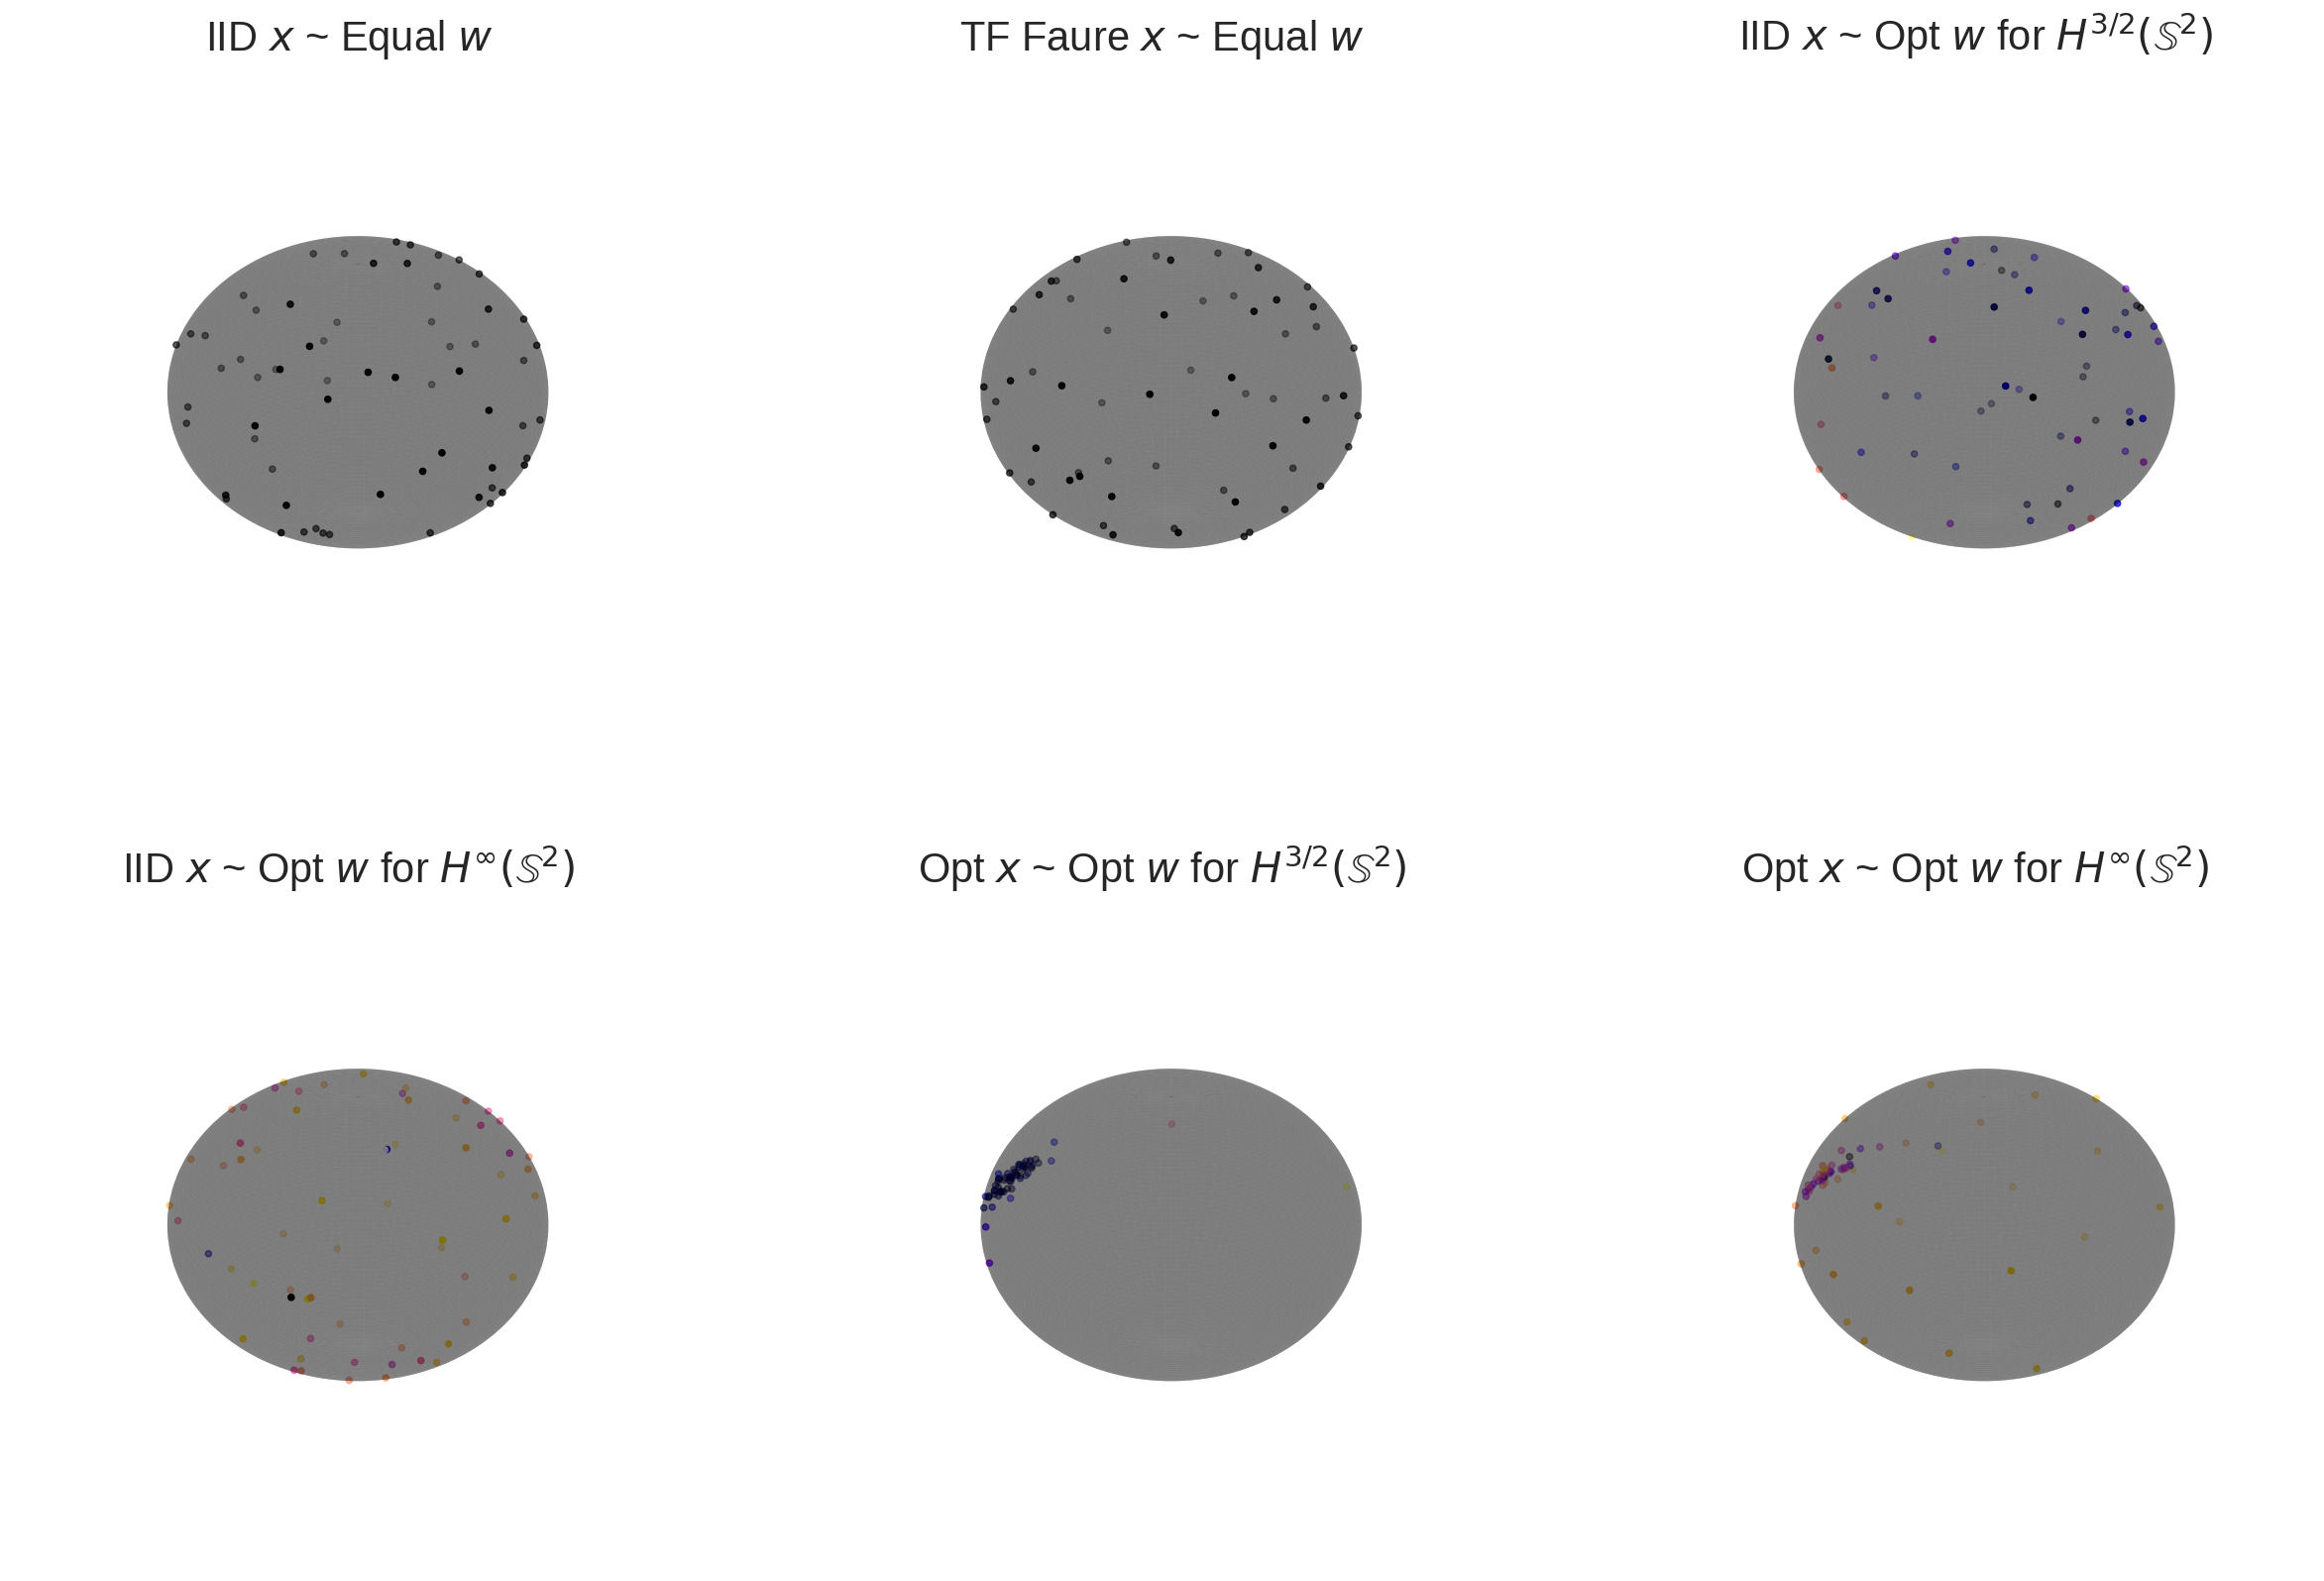

In [122]:
def get_spheres_fig_ax(nrows=1,ncols=1,showaxis=False,figwidth=PW,alpha=.3):
    fig,ax = pyplot.subplots(nrows=nrows,ncols=ncols,figsize=(figwidth,figwidth/ncols*nrows),subplot_kw={"projection":"3d"})
    ax = np.atleast_1d(ax).reshape((nrows,ncols))
    phimesh,thetamesh = torch.meshgrid(torch.linspace(0,np.pi,100),torch.linspace(0,2*np.pi,100),indexing="ij")
    xmesh = torch.sin(phimesh)*torch.cos(thetamesh)
    ymesh = torch.sin(phimesh)*torch.sin(thetamesh)
    zmesh = torch.cos(phimesh)
    for i in range(nrows):
        for j in range(ncols):
            ax[i,j].plot_surface(xmesh,ymesh,zmesh,rstride=1,cstride=1,color='k',alpha=alpha,linewidth=0)
            if not showaxis:
                ax[i,j].axis("off")
    return fig,ax
rng = torch.Generator().manual_seed(17)
n = 2**6
data = {
    r"IID $x$ ~ Equal $w$": get_sphere_iid_x_equal_w(n,rng), 
    r"TF Faure $x$ ~ Equal $w$": get_sphere_ldtf_x_equal_w(n,rng),
    r"IID $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$": get_sphere_iid_x_opt_w_A(n,rng),
    r"IID $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$": get_sphere_iid_x_opt_w_B(n,rng),
    r"Opt $x$ ~ Opt $w$ for $H^{3/2}(\mathbb{S}^2)$": get_sphere_opt_x_opt_w_A(n,rng),
    r"Opt $x$ ~ Opt $w$ for $H^\infty(\mathbb{S}^2)$": get_sphere_opt_x_opt_w_B(n,rng),
}
nrows,ncols = 2,3
fig,ax = get_spheres_fig_ax(nrows=nrows,ncols=ncols)
for j,(key,(x,w)) in enumerate(data.items()):
    j1,j2 = j//ncols,j%ncols
    assert torch.allclose(torch.linalg.norm(x,dim=-1),torch.ones(1))
    ax[j1,j2].scatter(x[:,0],x[:,1],x[:,2],cmap="gnuplot2",c=w)
    ax[j1,j2].set_title(key)